In [ ]:
# Import thư viện
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# Set random seeds cho reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [ ]:
# Load IMDB dataset
num_words = 10000  # Giữ lại 10,000 từ phổ biến nhất
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=num_words)

# Lấy word index để decode reviews
word_index = tf.keras.datasets.imdb.get_word_index()
word_index = {k: (v+3) for k, v in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2
word_index["<UNUSED>"] = 3

# Tạo reverse mapping
reverse_word_index = {v: k for k, v in word_index.items()}

def decode_review(text):
    """Decode integer sequence thành text"""
    return ' '.join([reverse_word_index.get(i, '?') for i in text])

# Thống kê cơ bản
print(f"\nTraining samples: {len(x_train)}")
print(f"Test samples: {len(x_test)}")
print(f"Positive samples (train): {np.sum(y_train)}")
print(f"Negative samples (train): {len(y_train)-np.sum(y_train)}")
print(f"Positive samples (test): {np.sum(y_test)}")
print(f"Negative samples (test): {len(y_test)-np.sum(y_test)}")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training samples: 25000
Test samples: 25000
Positive samples (train): 12500
Negative samples (train): 12500
Positive samples (test): 12500
Negative samples (test): 12500


In [ ]:
# Phân tích độ dài review
train_lengths = [len(review) for review in x_train]
test_lengths = [len(review) for review in x_test]

print(f"\nTraining review lengths:")
print(f"  Min length: {np.min(train_lengths)}")
print(f"  Max length: {np.max(train_lengths)}")
print(f"  Mean length: {np.mean(train_lengths):.2f}")
print(f"  Median length: {np.median(train_lengths):.2f}")

print(f"\nTest review lengths:")
print(f"  Min length: {np.min(test_lengths)}")
print(f"  Max length: {np.max(test_lengths)}")
print(f"  Mean length: {np.mean(test_lengths):.2f}")
print(f"  Median length: {np.median(test_lengths):.2f}")


Training review lengths:
  Min length: 11
  Max length: 2494
  Mean length: 238.71
  Median length: 178.00

Test review lengths:
  Min length: 7
  Max length: 2315
  Mean length: 230.80
  Median length: 174.00


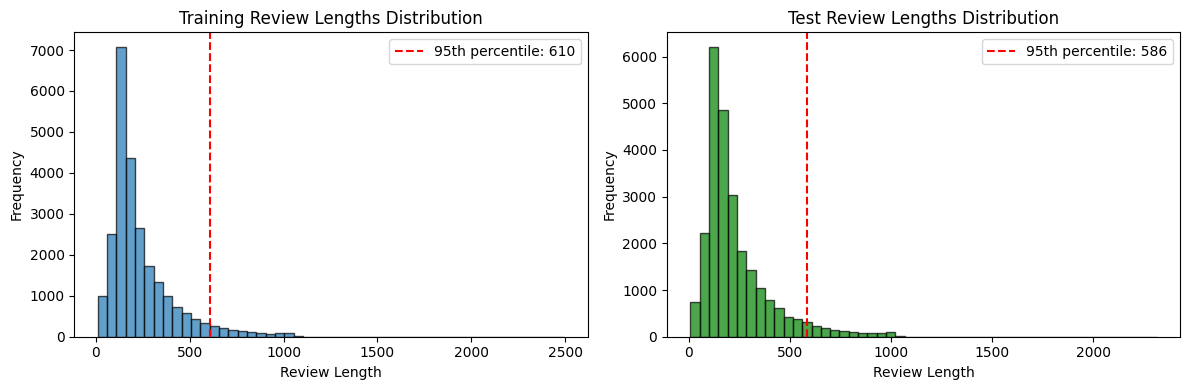

In [ ]:
# Visualize phân bố độ dài review
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Training Review Lengths Distribution')
axes[0].set_xlabel('Review Length')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.percentile(train_lengths, 95), color='red', linestyle='--', 
                label=f"95th percentile: {np.percentile(train_lengths, 95):.0f}")
axes[0].legend()

axes[1].hist(test_lengths, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Test Review Lengths Distribution')
axes[1].set_xlabel('Review Length')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.percentile(test_lengths, 95), color='red', linestyle='--',
                label=f"95th percentile: {np.percentile(test_lengths, 95):.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('review_lengths_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Hiển thị sample reviews
print("\n" + "="*50)
print("SAMPLE POSITIVE REVIEWS:")
print("="*50)

sample_positive_idx = np.where(y_train == 1)[0][:2]
for idx in sample_positive_idx:
    print(f"\nReview (positive):")
    print(decode_review(x_train[idx])[:500])  # Chỉ hiển thị 500 ký tự đầu
    print("-"*50)

print("\n" + "="*50)
print("SAMPLE NEGATIVE REVIEWS:")
print("="*50)

sample_negative_idx = np.where(y_train == 0)[0][:2]
for idx in sample_negative_idx:
    print(f"\nReview (negative):")
    print(decode_review(x_train[idx])[:500])
    print("-"*50)


SAMPLE POSITIVE REVIEWS:

Review (positive):
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would re
--------------------------------------------------

Review (positive):
<START> the <UNK> <UNK> at storytelling the traditional sort many years after the event i can still see in my <UNK> eye an elderly lady my friend's mother retelling the battle of <UNK> she makes the characters come alive her passion is that of an eye witness one to the events on the <UNK> heath a mile or so from where she lives br br of course it happened many years before she wa

In [ ]:
# Tiền xử lý: Padding sequences
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Chọn maxlen dựa trên phân tích độ dài (sử dụng 95th percentile)
maxlen = 500
print(f"Using maxlen: {maxlen}")

# Pad sequences
x_train_pad = pad_sequences(x_train, maxlen=maxlen)
x_test_pad = pad_sequences(x_test, maxlen=maxlen)

print(f"\nAfter padding:")
print(f"x_train shape: {x_train_pad.shape}")
print(f"x_test shape: {x_test_pad.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Using maxlen: 500

After padding:
x_train shape: (25000, 500)
x_test shape: (25000, 500)
y_train shape: (25000,)
y_test shape: (25000,)


In [ ]:
# Xây dựng mô hình LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Model architecture
model_lstm = Sequential([
    Embedding(input_dim=num_words, output_dim=128, input_length=maxlen),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2, return_sequences=False),
    Dense(1, activation='sigmoid')
])

# Compile model
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model summary
print("LSTM Model Architecture:")
model_lstm.summary()

LSTM Model Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_lstm_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train model
print("Training LSTM model...")
history_lstm = model_lstm.fit(
    x_train_pad, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Training LSTM model...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.6671 - loss: 0.5969
Epoch 1: val_accuracy improved from None to 0.83560, saving model to best_lstm_model.h5



Epoch 1: finished saving model to best_lstm_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 107s 658ms/step - accuracy: 0.7499 - loss: 0.5067 - val_accuracy: 0.8356 - val_loss: 0.3827
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.8360 - loss: 0.3972
Epoch 2: val_accuracy improved from 0.83560 to 0.84800, saving model to best_lstm_model.h5



Epoch 2: finished saving model to best_lstm_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 107s 682ms/step - accuracy: 0.8493 - loss: 0.3642 - val_accuracy: 0.8480 - val_loss: 0.3561
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 750ms/step - accuracy: 0.8717 - loss: 0.3175
Epoch 3: val_accuracy did not improve from 0.84800
157/157 ━━━━━━━━━━━━━━━━━━━━ 123s 785ms/step - accuracy: 0.8775 - loss: 0.3055 - val_accuracy: 0.8382 - val_loss: 0.3869
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.8880 - loss: 0.2814
Epoch 4: val_accuracy did not improve from 0.84800
157/157 ━━━━━━━━━━━━━━━━━━━━ 126s 799ms/step - accuracy: 0.8963 - loss: 0.2621 - val_accuracy: 0.8426 - val_loss: 0.3762
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 729ms/step - accuracy: 0.9064 - loss: 0.2486
Epoch 5: val_accuracy improved from 0.84800 to 0.85660, saving model to best_lstm_model.h5



Epoch 5: finished saving model to best_lstm_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 119s 760ms/step - accuracy: 0.9101 - loss: 0.2379 - val_accuracy: 0.8566 - val_loss: 0.3728
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [ ]:
# Xây dựng mô hình CNN-1D
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalMaxPooling1D, Flatten

model_cnn = Sequential([
    Embedding(input_dim=num_words, output_dim=128, input_length=maxlen),
    Conv1D(32, 7, activation='relu'),
    MaxPooling1D(5),
    Conv1D(32, 7, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile model
model_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model summary
print("CNN-1D Model Architecture:")
model_cnn.summary()

CNN-1D Model Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_cnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train model
print("Training CNN-1D model...")
history_cnn = model_cnn.fit(
    x_train_pad, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Training CNN-1D model...
Epoch 1/10
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5723 - loss: 0.6593
Epoch 1: val_accuracy improved from None to 0.86040, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.6827 - loss: 0.5628 - val_accuracy: 0.8604 - val_loss: 0.3344
Epoch 2/10
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8670 - loss: 0.3256
Epoch 2: val_accuracy did not improve from 0.86040
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.8886 - loss: 0.2817 - val_accuracy: 0.8550 - val_loss: 0.3746
Epoch 3/10
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9257 - loss: 0.2106
Epoch 3: val_accuracy improved from 0.86040 to 0.87040, saving model to best_cnn_model.h5



Epoch 3: finished saving model to best_cnn_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.9380 - loss: 0.1790 - val_accuracy: 0.8704 - val_loss: 0.3733
Epoch 4/10
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9405 - loss: 0.1619
Epoch 4: val_accuracy improved from 0.87040 to 0.87380, saving model to best_cnn_model.h5



Epoch 4: finished saving model to best_cnn_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.9468 - loss: 0.1428 - val_accuracy: 0.8738 - val_loss: 0.3986
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


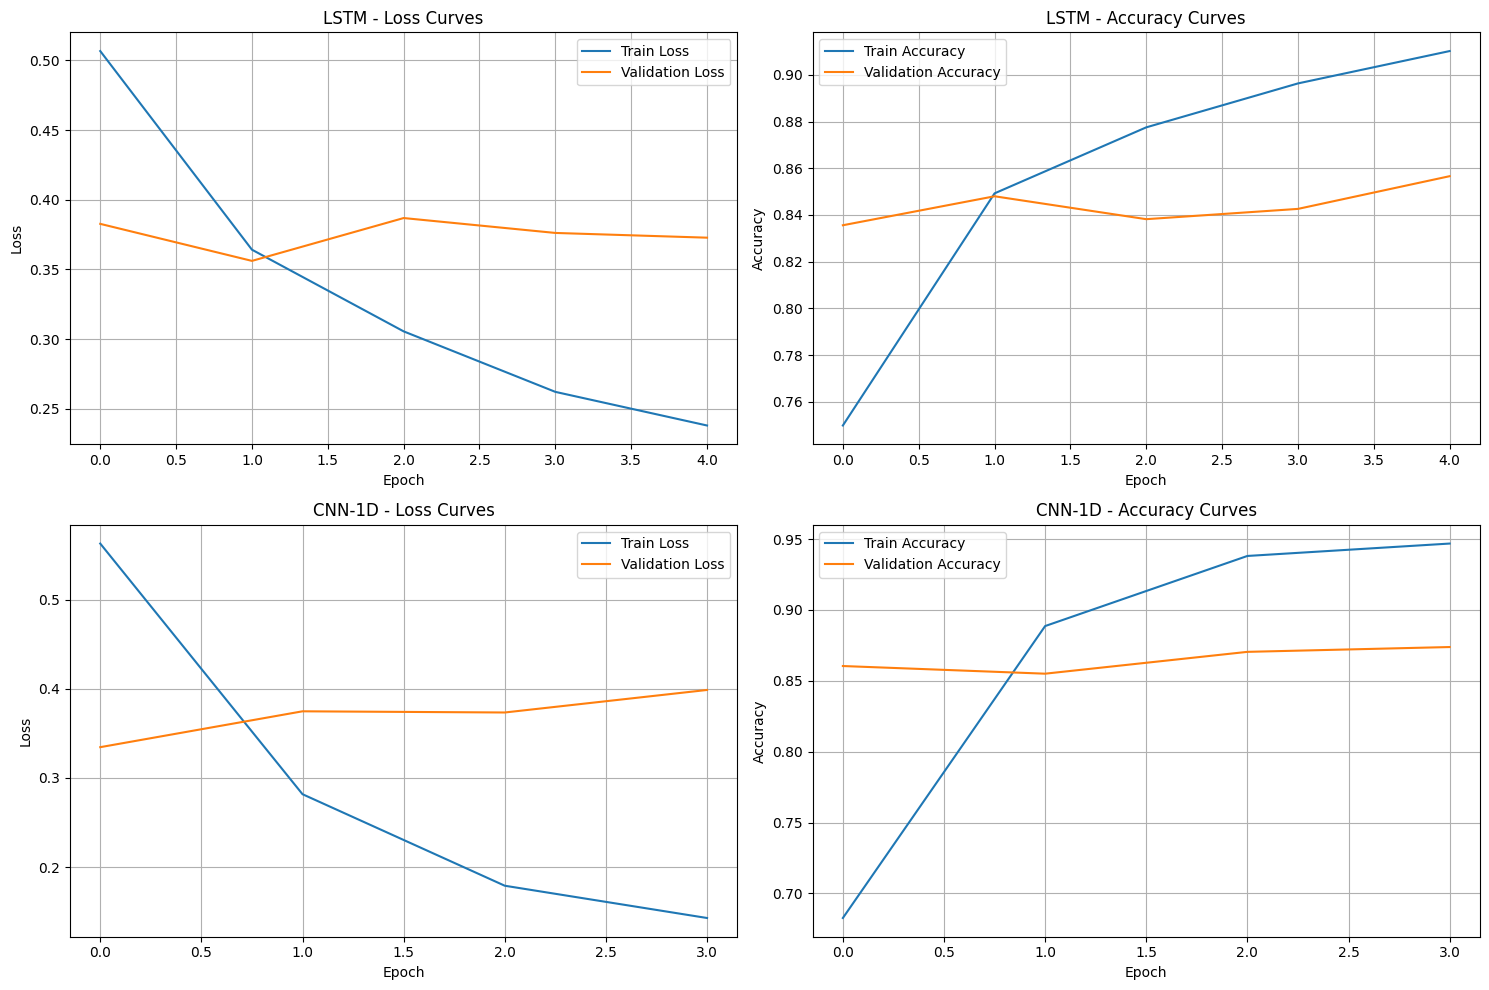

In [ ]:
# Visualize training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# LSTM loss
axes[0, 0].plot(history_lstm.history['loss'], label='Train Loss')
axes[0, 0].plot(history_lstm.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('LSTM - Loss Curves')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# LSTM accuracy
axes[0, 1].plot(history_lstm.history['accuracy'], label='Train Accuracy')
axes[0, 1].plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_title('LSTM - Accuracy Curves')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# CNN loss
axes[1, 0].plot(history_cnn.history['loss'], label='Train Loss')
axes[1, 0].plot(history_cnn.history['val_loss'], label='Validation Loss')
axes[1, 0].set_title('CNN-1D - Loss Curves')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

# CNN accuracy
axes[1, 1].plot(history_cnn.history['accuracy'], label='Train Accuracy')
axes[1, 1].plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
axes[1, 1].set_title('CNN-1D - Accuracy Curves')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Đánh giá LSTM trên test set
print("LSTM MODEL EVALUATION")

lstm_loss, lstm_accuracy = model_lstm.evaluate(x_test_pad, y_test, verbose=0)
print(f"Test Loss: {lstm_loss:.4f}")
print(f"Test Accuracy: {lstm_accuracy:.4f}")

# Đánh giá CNN trên test set
print("\n" + "="*50)
print("CNN-1D MODEL EVALUATION")
print("="*50)

cnn_loss, cnn_accuracy = model_cnn.evaluate(x_test_pad, y_test, verbose=0)
print(f"Test Loss: {cnn_loss:.4f}")
print(f"Test Accuracy: {cnn_accuracy:.4f}")

# So sánh
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(f"LSTM  - Accuracy: {lstm_accuracy:.4f}")
print(f"CNN-1D - Accuracy: {cnn_accuracy:.4f}")
print(f"Best model: {'LSTM' if lstm_accuracy > cnn_accuracy else 'CNN-1D'}")

LSTM MODEL EVALUATION
Test Loss: 0.3553
Test Accuracy: 0.8477

CNN-1D MODEL EVALUATION
Test Loss: 0.3411
Test Accuracy: 0.8540

MODEL COMPARISON
LSTM  - Accuracy: 0.8477
CNN-1D - Accuracy: 0.8540
Best model: CNN-1D


782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 37ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
LSTM - CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.86      0.83      0.85     12500
    Positive       0.84      0.86      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000


CNN-1D - CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.87      0.84      0.85     12500
    Positive       0.84      0.87      0.86     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



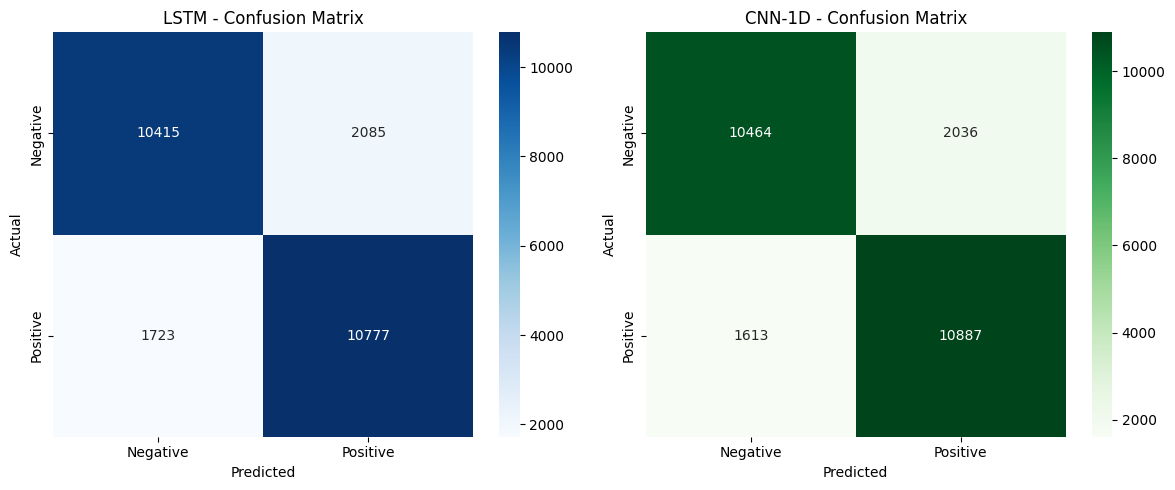

In [ ]:
# Dự đoán với LSTM
y_pred_lstm = (model_lstm.predict(x_test_pad) > 0.5).astype(int)
y_pred_cnn = (model_cnn.predict(x_test_pad) > 0.5).astype(int)

# LSTM Classification Report
print("="*50)
print("LSTM - CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred_lstm, target_names=['Negative', 'Positive']))

# CNN Classification Report
print("\n" + "="*50)
print("CNN-1D - CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred_cnn, target_names=['Negative', 'Positive']))

# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LSTM Confusion Matrix
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('LSTM - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Negative', 'Positive'])
axes[0].set_yticklabels(['Negative', 'Positive'])

# CNN Confusion Matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('CNN-1D - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['Negative', 'Positive'])
axes[1].set_yticklabels(['Negative', 'Positive'])

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 37ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


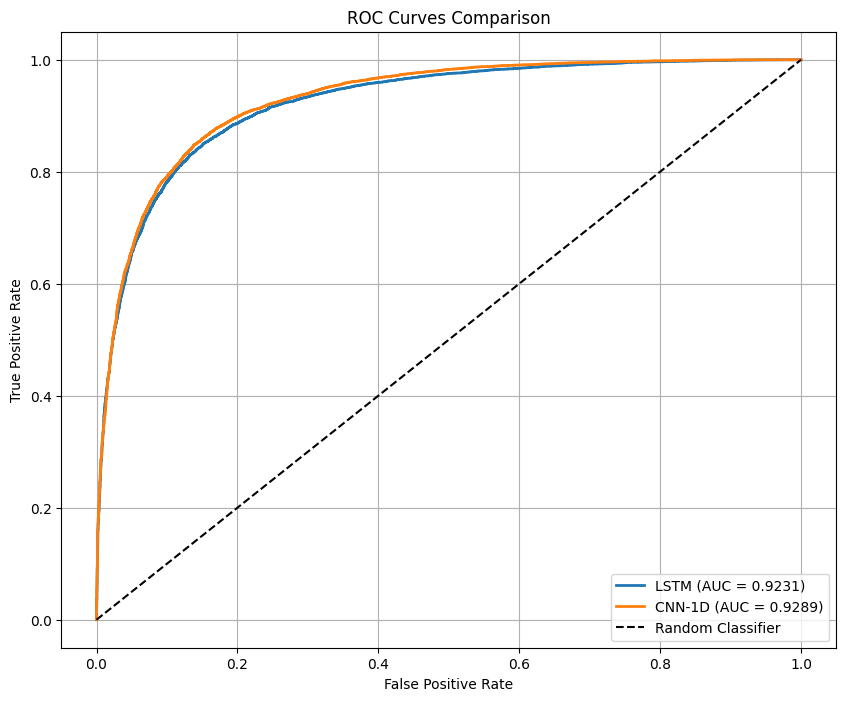

In [ ]:
# ROC Curves
y_pred_proba_lstm = model_lstm.predict(x_test_pad)
y_pred_proba_cnn = model_cnn.predict(x_test_pad)

fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_pred_proba_lstm)
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_pred_proba_cnn)

auc_lstm = auc(fpr_lstm, tpr_lstm)
auc_cnn = auc(fpr_cnn, tpr_cnn)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC = {auc_lstm:.4f})', linewidth=2)
plt.plot(fpr_cnn, tpr_cnn, label=f'CNN-1D (AUC = {auc_cnn:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True)
plt.savefig('roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Lưu models
model_lstm.save('sentiment_analysis_lstm.h5')
model_cnn.save('sentiment_analysis_cnn.h5')

# Tổng kết kết quả
results = {
    'Model': ['LSTM', 'CNN-1D'],
    'Test Accuracy': [lstm_accuracy, cnn_accuracy],
    'Test Loss': [lstm_loss, cnn_loss],
    'AUC': [auc_lstm, auc_cnn]
}

results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("FINAL RESULTS SUMMARY")
print("="*50)
print(results_df)

# Save results to CSV
results_df.to_csv('model_comparison_results.csv', index=False)
print("\nResults saved to 'model_comparison_results.csv'")


FINAL RESULTS SUMMARY
    Model  Test Accuracy  Test Loss       AUC
0    LSTM        0.84768   0.355321  0.923073
1  CNN-1D        0.85404   0.341091  0.928905

Results saved to 'model_comparison_results.csv'


In [ ]:
# Hàm tiền xử lý và dự đoán review mới
def predict_sentiment(text, model, maxlen=500):
    """
    Dự đoán sentiment cho review mới
    """
    # Convert text to sequence
    words = text.lower().split()
    sequence = []
    for word in words:
        if word in word_index:
            sequence.append(word_index[word])
        else:
            sequence.append(2)  # <UNK>
    
    # Pad sequence
    padded = pad_sequences([sequence], maxlen=maxlen)
    
    # Predict
    prediction = model.predict(padded, verbose=0)[0][0]
    sentiment = "Positive" if prediction > 0.5 else "Negative"
    confidence = prediction if prediction > 0.5 else 1 - prediction
    
    return sentiment, confidence * 100

# Test với một số reviews
test_reviews = [
    "This movie is absolutely fantastic! Great acting and amazing story!",
    "Terrible movie, waste of time. Poor acting and boring plot.",
    "The film was okay, nothing special but not terrible either."
]

print("\n" + "="*50)
print("TEST WITH NEW REVIEWS (Using LSTM Model)")
print("="*50)

for review in test_reviews:
    sentiment, confidence = predict_sentiment(review, model_lstm)
    print(f"\nReview: {review}")
    print(f"Sentiment: {sentiment} (Confidence: {confidence:.2f}%)")


TEST WITH NEW REVIEWS (Using LSTM Model)

Review: This movie is absolutely fantastic! Great acting and amazing story!
Sentiment: Positive (Confidence: 55.07%)

Review: Terrible movie, waste of time. Poor acting and boring plot.
Sentiment: Negative (Confidence: 98.48%)

Review: The film was okay, nothing special but not terrible either.
Sentiment: Negative (Confidence: 97.23%)
